# Stars 5 and 6: Metrological Efficiency Indicator and placement among the Challenge participants

**Datasets.** DIC Challenge 2.0 (Reu et al., 2022): Star 5 (±0.5 px displacement) and Star 6 (±5 % strain), both noisy, period 10→300 px, each with an undeformed noise-floor image.

**Metrics**
- **n**, measurement resolution: 1σ along the centre row of the noise-floor image
- **l10%**, spatial resolution: the period at which a 12th-order polynomial fit of measured/commanded first rises through 0.9 (the Challenge's rule)
- **MEI** = n·l10% for displacement, **n·l10%²** for strain; lower is better. Each code is summarised by the mean of its three lowest values.

**On the strain exponent.** The paper's Eq. 3 writes n²·l for strain, but its strain section and Fig. 12 (slope −2 of log n against log l) both make n·l² the invariant, and n·l² reproduces the magnitudes of its Fig. 13 while n²·l would give values near 10⁻⁴. n·l² is used.

**Method.** The engine is run through the CLI; every participant's submitted line cuts are then analysed by **the same code** (`validation.star.analyse_line_cut`), so any quirk of fitting or crossing detection applies to all codes alike. The participant results are checked against the paper's Figs. 11 and 13 before the engine is placed among them.

**What this establishes for Chapter 5**
1. The analysis pipeline reproduces the Challenge's published results from the raw submissions.
2. The engine's displacement and strain MEI, placed among the 26 and 23 participant codes. Each engine variant is ranked against the participants alone, and the primary placement uses only the engine's subset series, so that the engine, like each participant, is summarised from one parameter series.
3. The strain estimator against the cascaded-filter theory, across a strain-window sweep.
4. Two methodological findings: l10% is blind to long-period dips, and strain MEI is not invariant to the strain window when the window is small relative to the subset's own resolution.

In [1]:
import os
import sys
from pathlib import Path

# The notebook lives in validation/notebooks/; the validation package lives at the repository root.
REPO = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

# Environment variables win, so another machine or a CI job runs the notebook unchanged.
CHALLENGE2 = Path(os.environ.get("DIC_CHALLENGE2", "~/Documents/dicsamples/2D-Challenge2")).expanduser()
RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser()

# True re-runs every configuration even when its output already exists.
FORCE = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from validation.runner import Dataset, SweepPoint, expand_grid, score_run
from validation.workflow import run_point, write_base_config
from validation.resolution import attenuation_theory, code_mei, fit_attenuation, theoretical_resolution
from validation.star import (STAR_SETS, STRAIN_GRADIENT, STRAIN_GREEN_LAGRANGE, analyse_line_cut,
                             band_height, centre_row, image_shape, plateau, write_band_roi)
from validation.truth import NoTruth
from validation.workflow import load_frame, row_cut, run_quality
from validation.participants import (classify_quantity, drop_superseded, harmonise_units,
                                     load_folder, not_submitted)

print("repo    :", REPO)
print("data    :", CHALLENGE2)
print("results :", RESULTS)

In [2]:
def star_dataset(star, name: str, frames: list[str]):
    """Base config for one Star set; subset, ROI band and search window are set per run."""
    base = {
        "session": {
            "image_dir": str(CHALLENGE2 / star.folder),
            "mode": "explicit",
            "reference_frame": star.reference,
            "explicit_frame_list": "frames.txt",
        },
        "setup": {"subset_size": 17, "step_size": 1},
        "correlation": {
            "search_size": 27,
            "correlation_mode": "spatial",
            "tracking_mode": "eulerian",
            "criterion_name": "znssd",
            "match_threshold": 0.6,
            "n_workers": 4,
            "search": {"method": "brute"},
            "refinement": {"method": "icgn", "shape_function": "affine"},
            "strain": {"method": "lagrange_q4", "strain_window": 5},
            "image_interpolation": {"method": "biquintic_spline"},
        },
    }
    config_path, runs_root = write_base_config(base, name, RESULTS)
    (config_path.parent / "frames.txt").write_text("\n".join(frames) + "\n")
    return Dataset(name, config_path, NoTruth("resolution study")), runs_root


def star_point(subset: int, shape: str, roi: Path, strain_window: int | None = None) -> SweepPoint:
    overrides = {
        "setup.subset_size": subset,
        "setup.step_size": 1,
        "setup.roi_mask": str(roi),
        # Shifts are below 0.5 px on the rows kept; the window only needs to exceed the subset.
        "correlation.search_size": subset + 10,
        "correlation.refinement.shape_function": shape,
    }
    if strain_window is not None:
        overrides["correlation.strain.method"] = "lagrange_q4"
        overrides["correlation.strain.strain_window"] = strain_window
    return SweepPoint(overrides)


## Geometry: one row of nodes at 1 px spacing

The Challenge protocol reports the centre row at 1 px spacing. The engine uses one isotropic step, so
step 1 over a 501×4000 image would be two million nodes per run. Instead each run gets a **horizontal ROI
band exactly one subset tall**, centred on the middle row. The engine erodes the ROI by the subset
half-width before placing nodes, leaving a single row: the centre row, at 1 px spacing. For strain, the
band is taller by the strain window so the centre row keeps a full window above and below it.

**No Eulerian→Lagrangian correction.** The Challenge 2.0 images come from a closed-form Boolean speckle
model with the true field defined at reference positions (their Eq. 2), which is what DIC reports.

In [3]:
PARAMS = [9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49]   # Local.Affine.B's subsets, the affine reference
SHAPES = ["affine", "quadratic"]
STRAIN_WINDOW = 5                                     # subset series; see the window sweep below
SW_SWEEP, SUBSET_SW = [5, 11, 21, 31, 41], 21

engine_rows = []


## Star 5: displacement

In [4]:
S5 = STAR_SETS["Star5"]
H5, W5 = image_shape(CHALLENGE2 / S5.folder / S5.reference)
ROW5 = centre_row(H5)
ds5, runs5 = star_dataset(S5, "star5", [S5.noise, S5.deformed])
print(f"{S5.folder}: {H5}x{W5}, centre row {ROW5}")

star5_runs = {}   # (shape, subset) -> run directory, kept for the figures below
for subset in PARAMS:
    roi = write_band_roi(runs5.parent / "roi" / f"band_{subset}.tiff", (H5, W5), band_height(subset))
    for shape in SHAPES:
        outcome = run_point(ds5, runs5, star_point(subset, shape, roi), repo=REPO, force=FORCE)
        if not outcome.ok:
            continue
        star5_runs[(shape, subset)] = outcome.output_dir
        x0, v = row_cut(outcome.output_dir, S5.deformed, "v_px", ROW5)
        nx, nv = row_cut(outcome.output_dir, S5.noise, "v_px", ROW5)
        engine_rows.append({"quantity": "displacement", "code": f"iCorrVision 2.0 ({shape})",
                            "parameter": subset, "strain_window": np.nan, "series": "subset",
                            "nonconverged_pct": run_quality(outcome.output_dir)["nonconverged_pct"],
                            **analyse_line_cut(S5, x0, v, nx, nv)})

Star5LargeNoisy: 501x4000, centre row 250
  e26e0053cd  reused  
  a5fdf2ff24  reused  


  4c557b52a3  reused  


  c0b74ee77b  reused  
  3b9a7b393e  reused  


  016b43bcda  reused  


  ea8c42fd64  reused  
  36a3f4144d  reused  


...

  ed13023bf3  reused  
  ceafe03a90  reused  


  a1e55ebb85  reused  


  aedea8f12c  reused  
  6f2a0a2189  reused  


  d451f15e3e  reused  


  dfb5408cfe  reused  


## Star 6: strain

**Amplitude.** "±5 % Lagrangian strain" is ambiguous between a gradient ∂v/∂Y = 0.05 and a Green–Lagrange
E_yy = 0.05 (2.5 % apart at the peak). The engine reports Green–Lagrange and is normalised by 0.05125, the
Green–Lagrange value of a 0.05 gradient. Participants are normalised by the paper's commanded 0.05, which
reproduces its Fig. 13; this favours them relative to the engine, since it inflates their
ratios. The plateau diagnostic below shows how strongly the participants' own results support the
Green–Lagrange reading, and the engine's strain MEI is also computed under the 0.05 normalisation
(`mei_gradnorm`) so the effect of the choice can be stated rather than assumed.

**Two series.** A subset series at a fixed 5-node window, then a strain-window sweep at subset 21. The
primary placement uses the subset series only; the window sweep is reported separately.

In [5]:
S6 = STAR_SETS["Star6"]
H6, W6 = image_shape(CHALLENGE2 / S6.folder / S6.reference)
ROW6 = centre_row(H6)
ds6, runs6 = star_dataset(S6, "star6", [S6.noise, S6.deformed])
print(f"{S6.folder}: {H6}x{W6}, centre row {ROW6}")

ENGINE_STRAIN_TRUE = STRAIN_GREEN_LAGRANGE
PARTICIPANT_STRAIN_TRUE = STRAIN_GRADIENT

def strain_run(subset: int, shape: str, sw: int, series: str):
    roi = write_band_roi(runs6.parent / "roi" / f"band_{subset}_sw{sw}.tiff",
                         (H6, W6), band_height(subset, sw))
    outcome = run_point(ds6, runs6, star_point(subset, shape, roi, sw), repo=REPO, force=FORCE)
    if not outcome.ok:
        return None
    x0, e = row_cut(outcome.output_dir, S6.deformed, "eyy", ROW6)
    nx, ne = row_cut(outcome.output_dir, S6.noise, "eyy", ROW6)
    alt = analyse_line_cut(S6, x0, e, nx, ne, amplitude=STRAIN_GRADIENT)
    engine_rows.append({"quantity": "strain", "code": f"iCorrVision 2.0 ({shape})",
                        "parameter": subset, "strain_window": sw, "series": series,
                        "nonconverged_pct": run_quality(outcome.output_dir)["nonconverged_pct"],
                        "l10_px_gradnorm": alt["l10_px"], "mei_gradnorm": alt["mei"],
                        **analyse_line_cut(S6, x0, e, nx, ne, amplitude=ENGINE_STRAIN_TRUE)})
    return x0, e

engine_strain_smallest = {}
for subset in PARAMS:
    for shape in SHAPES:
        cut = strain_run(subset, shape, STRAIN_WINDOW, "subset")
        if cut is not None and subset == min(PARAMS):
            engine_strain_smallest[shape] = cut

for shape in SHAPES:
    for sw in SW_SWEEP:
        if sw == STRAIN_WINDOW and SUBSET_SW in PARAMS:
            continue  # already run in the subset series
        strain_run(SUBSET_SW, shape, sw, "window")

engine = pd.DataFrame(engine_rows)
print(len(engine), "engine curves")
print("non-converged nodes, % of valid, largest per quantity and shape:")
print(engine.groupby(["quantity", "code"]).nonconverged_pct.max().round(3))

Star6StrainNoisy: 501x4000, centre row 250
  044e75c940  reused  


  807112e757  reused  


  a871b27311  reused  


  b01a0a1370  reused  


  66eb839aa6  reused  


...

  6deab67448  reused  


  cea2ac7084  reused  


  d46479144a  reused  


  c8c82c4c5b  reused  


52 engine curves
non-converged nodes, % of valid, largest per quantity and shape:
quantity      code                       
displacement  iCorrVision 2.0 (affine)        0.364
              iCorrVision 2.0 (quadratic)    10.612
strain        iCorrVision 2.0 (affine)        0.206
              iCorrVision 2.0 (quadratic)     9.984
Name: nonconverged_pct, dtype: float64


## Strain window sweep against the cascaded-filter theory

The strain window acts as a second low-pass filter after the subset. The prediction multiplies the
subset's Savitzky–Golay response by the response of a least-squares slope over the window
(`attenuation_theory(..., strain_window=sw)`).

**Why MEI falls with the window for affine.** The subset already limits resolution. While the strain
window is narrower than that, widening it suppresses noise quickly and costs almost no resolution; once it
dominates, n and l trade at the fixed rate MEI assumes, and MEI levels off. A quadratic subset blurs far
less (0.32× affine), so its window starts to dominate almost at once. The sweep below does not show a flat
quadratic MEI, however: it is lowest at the smallest windows and rises by about half across the sweep. At
the smallest windows the measured quadratic resolution is also coarser than the cascaded theory predicts,
which is the pattern-information limit seen in Star 1 for small quadratic subsets. The optimal strain window
therefore depends on the shape function; that, not a flat MEI, is the finding.

In [6]:
ORDER = {"affine": 1, "quadratic": 2}
sweep = engine[(engine.quantity == "strain") & (engine.parameter == SUBSET_SW)].copy()
sweep["vsg_px"] = SUBSET_SW + sweep.strain_window - 1
sweep["l10_theory"] = [theoretical_resolution(SUBSET_SW, ORDER[c.split("(")[1][:-1]], strain_window=int(sw))
                       for c, sw in zip(sweep.code, sweep.strain_window)]
sweep["difference_%"] = 100 * (sweep.l10_px / sweep.l10_theory - 1)
window_table = (sweep.sort_values(["code", "strain_window"])
                [["code", "strain_window", "vsg_px", "n", "l10_px", "l10_theory", "difference_%", "mei"]])
window_table.round(5)


,code,strain_window,vsg_px,n,l10_px,l10_theory,difference_%,mei
28,iCorrVision 2.0 (affine),5.0,25.0,0.00130,85.25559,85.00405,0.29591,9.44838
44,iCorrVision 2.0 (affine),11.0,31.0,0.00077,88.34050,90.06093,-1.91029,5.99088
45,iCorrVision 2.0 (affine),21.0,41.0,0.00047,102.99754,105.32979,-2.21424,5.00535
46,iCorrVision 2.0 (affine),31.0,51.0,0.00031,123.17950,126.45493,-2.59020,4.71538
47,iCorrVision 2.0 (affine),41.0,61.0,0.00021,153.61755,151.01586,1.72279,4.92546
29,iCorrVision 2.0 (quadratic),5.0,25.0,0.00265,35.56022,29.14932,21.99332,3.34827
48,iCorrVision 2.0 (quadratic),11.0,31.0,0.00169,42.71274,38.79182,10.10758,3.09107
49,iCorrVision 2.0 (quadratic),21.0,41.0,0.00090,71.50570,65.65817,8.90603,4.62153
50,iCorrVision 2.0 (quadratic),31.0,51.0,0.00050,96.98861,95.83475,1.20401,4.70306
51,iCorrVision 2.0 (quadratic),41.0,61.0,0.00028,124.96458,126.50741,-1.21956,4.40437


## Participants

**Loading.** The quantity comes from each folder's name (the quantity word is right; the Star numbers in
the distributed names appear swapped) and is cross-checked by a per-code magnitude vote. Units are
harmonised per code: plateaus near 100× or 10⁶× the amplitude are rescaled as percent or microstrain;
anything matching no unit is excluded and listed. Resubmissions (`_New`) replace their originals under
the original name, as in the paper.

In [7]:
participant_tables, unit_reports, dropped = {}, {}, {}
for folder in sorted((CHALLENGE2 / "Results").iterdir()):
    if not folder.is_dir():
        continue
    table = load_folder(folder)
    if table.empty:
        continue
    quantity = "displacement" if folder.name.lower().startswith("displacement") else "strain"
    voted = classify_quantity(table)
    if voted != quantity:
        print(f"WARNING: {folder.name} is named {quantity} but its codes vote {voted}")
    table, dropped[quantity] = drop_superseded(table)
    amplitude = 0.5 if quantity == "displacement" else STRAIN_GRADIENT
    table, unit_reports[quantity] = harmonise_units(table, amplitude)
    participant_tables[quantity] = table
    unit_reports[quantity]["pixel_repaired"] = unit_reports[quantity].code.map(
        table.groupby("code").pixel_repaired.any()).fillna(False)
    unit_reports[quantity]["not_submitted"] = False
    for code_name in not_submitted(folder):
        unit_reports[quantity].loc[len(unit_reports[quantity])] = {
            "code": code_name, "unit": "NOT SUBMITTED", "not_submitted": True}
    print(f"{folder.name:28s} -> {quantity:12s} {table.code.nunique()} codes"
          + (f"; superseded: {dropped[quantity]}" if dropped[quantity] else ""))


DisplacementResults_Star6    -> displacement 26 codes


StrainResults_Star5          -> strain       23 codes


**Pixel-column repairs.** An audit of the participant files whose pixel column could not be used as given:
where the column breaks, and how. The loader's repair rule is described in `validation/participants.py`.

In [8]:
import validation.participants as P

flagged = [("DisplacementResults_Star6", "Local.Affine.D"), ("DisplacementResults_Star6", "Local.Affine.G"),
           ("DisplacementResults_Star6", "Local.Quad.B"), ("StrainResults_Star5", "Global.B"),
           ("StrainResults_Star5", "Local.Quad.B")]
for folder, name in flagged:
    path = CHALLENGE2 / "Results" / folder / f"{name}.csv"
    if not path.exists():
        print(f"{name:15s} ({folder[:12]}) not found")
        continue
    lines = path.read_text(errors="replace").splitlines()
    start = next(i for i, l in enumerate(lines) if l.lower().startswith("pixel")) + 1
    px = np.array([P._to_float(l.split(",")[0]) for l in lines[start:] if l.strip()])
    px = px[np.isfinite(px)]
    steps = np.diff(px)
    bad = np.flatnonzero((steps <= 0) | (steps > P.MAX_PIXEL_STEP))
    where = ", ".join(f"row {b}: {px[b]:g} -> {px[b + 1]:g}" for b in bad[:3])
    print(f"{name:15s} ({folder[:12]}) n={px.size}, {px.min():g}..{px.max():g}, "
          f"{bad.size} bad steps{': ' + where if bad.size else ''}")

Local.Affine.D  (Displacement) n=3986, 7..3990, 2693 bad steps: row 993: 1000 -> 1000, row 994: 1000 -> 1000, row 995: 1000 -> 1000
Local.Affine.G  (Displacement) n=4001, 1..4000, 1 bad steps: row 9: 10 -> 10
Local.Quad.B    (Displacement) n=3986, 7..3990, 2693 bad steps: row 993: 1000 -> 1000, row 994: 1000 -> 1000, row 995: 1000 -> 1000
Global.B        (StrainResult) n=4000, 1..40000, 1 bad steps: row 3998: 3999 -> 40000
Local.Quad.B    (StrainResult) n=3966, 17..3980, 2684 bad steps: row 983: 1000 -> 1000, row 984: 1000 -> 1000, row 985: 1000 -> 1000


**Strain amplitude diagnostic.** Long-period plateau at each code's smallest parameter, where attenuation is
smallest. 0.05125 is the Green–Lagrange value of a 0.05 gradient; 0.050 would be the gradient itself;
values near 0.048 suggest a logarithmic measure (ln 1.05 = 0.0488). The spread between codes is several
times the 2.5 % that separates the two readings, so the participants' median and its standard error, not
any single code, is what bears on the question.

In [9]:
strain = participant_tables["strain"]
diag = []
for code_name, g in strain[strain.image == "deformed"].groupby("code"):
    s = g[g.config == g.loc[g.parameter.idxmin(), "config"]]
    diag.append({"code": code_name, "parameter": s.parameter.iloc[0],
                 "plateau": plateau(S6, s.pixel.to_numpy() - 1, s.value.to_numpy())})
for shape, (x0, e) in engine_strain_smallest.items():
    diag.append({"code": f"iCorrVision 2.0 ({shape})", "parameter": min(PARAMS),
                 "plateau": plateau(S6, x0, e)})
diag = pd.DataFrame(diag)
others = diag[~diag.code.str.startswith("iCorrVision")].plateau
print(f"gradient reading {STRAIN_GRADIENT:.5f}, Green-Lagrange reading {STRAIN_GREEN_LAGRANGE:.5f}")
print(f"participants: median {others.median():.5f}, mean {others.mean():.5f} "
      f"± {others.std(ddof=1) / np.sqrt(others.size):.5f} (standard error), n = {others.size}")
diag.round(5)

gradient reading 0.05000, Green-Lagrange reading 0.05125
participants: median 0.05087, mean 0.05103 ± 0.00050 (standard error), n = 23


,code,parameter,plateau
0,Global.A,25.0,0.04864
1,Global.B,8.0,0.05081
2,Global.C,0.0,0.05351
3,Global.D,8.0,0.05203
4,Global.E,10.0,0.04938
5,Global.F,20.0,0.04856
6,Global.G,10.0,0.05000
7,Local.Affine.A,13.0,0.05326
8,Local.Affine.B,9.0,0.05130
9,Local.Affine.D,31.0,0.05645


**Analysis.** Each configuration is a noise column paired with a deformed column (`config`). Parameter
labels are display-only: some files give fewer labels than columns, so grouping by label would merge
different runs.

In [10]:
participant_rows = []
for quantity, table in participant_tables.items():
    star = S5 if quantity == "displacement" else S6
    amplitude = star.amplitude if quantity == "displacement" else PARTICIPANT_STRAIN_TRUE
    for (code_name, config), g in table.groupby(["code", "config"]):
        d = g[g.image == "deformed"].sort_values("pixel")
        n = g[g.image == "noise"].sort_values("pixel")
        if d.value.notna().sum() < 50:
            continue
        m = analyse_line_cut(star, d.pixel.to_numpy() - 1, d.value.to_numpy(),
                             n.pixel.to_numpy() - 1, n.value.to_numpy(), amplitude=amplitude)
        participant_rows.append({"quantity": quantity, "code": code_name,
                                 "parameter": d.parameter.iloc[0], "config": config, **m})

participants = pd.DataFrame(participant_rows)
everyone = pd.concat([participants, engine], ignore_index=True)
print(len(participants), "participant curves,", len(engine), "engine curves")


354 participant curves, 52 engine curves


## Code MEI (cf. Reu et al. Figs. 11 and 13)

**Acceptance check before reading the engine's bars:** the participant bars must reproduce the paper's
figures. Known deviation: Misc.E strain (a non-monotonic curve that overshoots to 1.2 and dips near
250 px, where a polynomial fit is least stable).

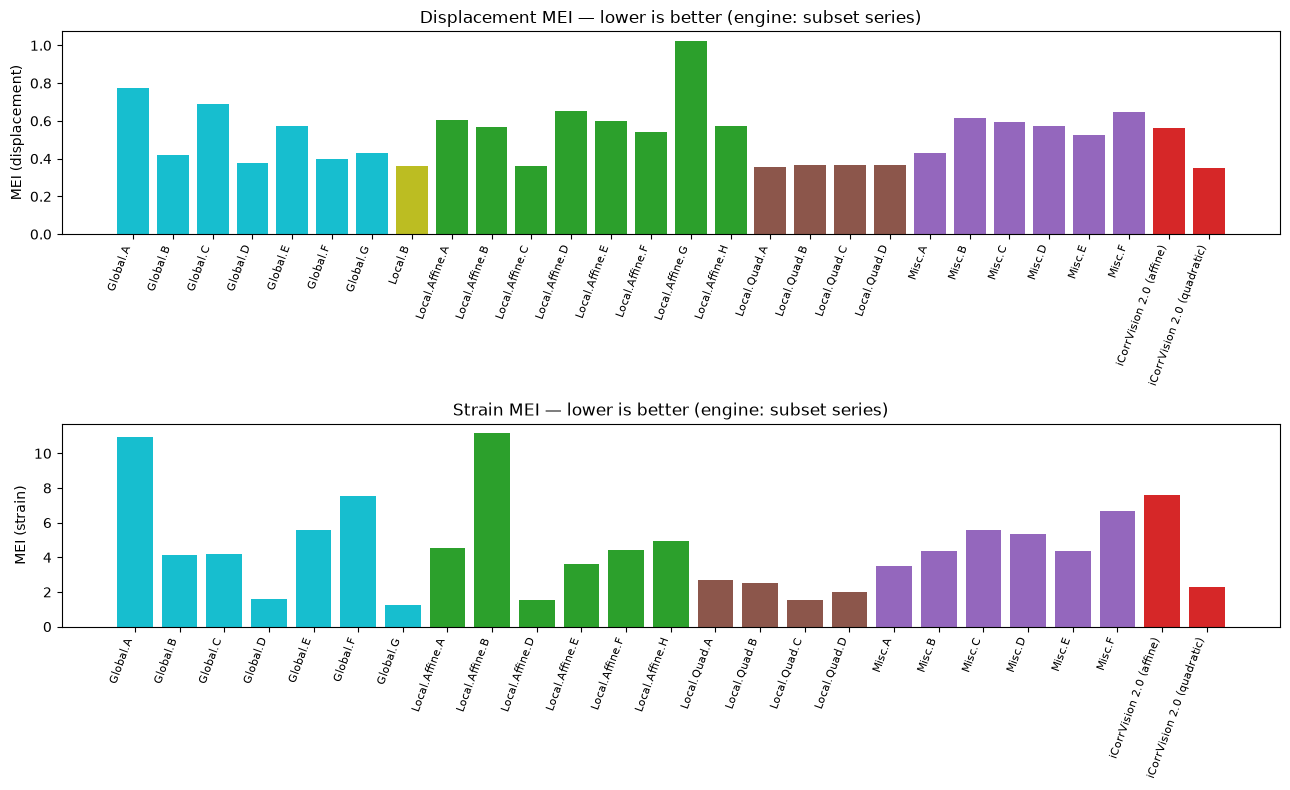

In [11]:
def family(code_name: str) -> str:
    if code_name.startswith("iCorrVision"):
        return "iCorrVision 2.0"
    for prefix in ("Local.Affine", "Local.Quad", "Global", "Misc", "Local"):
        if code_name.startswith(prefix):
            return prefix
    return "other"


PALETTE = {"Local.Affine": "tab:green", "Local.Quad": "tab:brown", "Global": "tab:cyan",
           "Misc": "tab:purple", "Local": "tab:olive", "iCorrVision 2.0": "tab:red", "other": "grey"}


def code_meis(curves: pd.DataFrame) -> pd.DataFrame:
    return (curves.groupby(["quantity", "code"]).mei.apply(code_mei)
            .rename("code_mei").reset_index())


is_engine = everyone.code.str.startswith("iCorrVision")
participant_mei = code_meis(everyone[~is_engine])
# Primary: the engine summarised from its subset series only, as each participant is from one series.
engine_primary = code_meis(everyone[is_engine & (everyone.series == "subset")])
# Secondary: all engine configurations pooled (subset series + strain-window sweep).
engine_pooled = code_meis(everyone[is_engine])

ranking = pd.concat([participant_mei, engine_primary], ignore_index=True)
ranking["family"] = ranking.code.map(family)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, quantity in zip(axes, ("displacement", "strain")):
    r = ranking[ranking.quantity == quantity].sort_values(["family", "code"])
    ax.bar(range(len(r)), r.code_mei, color=r.family.map(PALETTE))
    ax.set_xticks(range(len(r)))
    ax.set_xticklabels(r.code, rotation=70, ha="right", fontsize=8)
    ax.set_ylabel(f"MEI ({quantity})")
    ax.set_title(f"{quantity.capitalize()} MEI — lower is better (engine: subset series)")
fig.tight_layout()

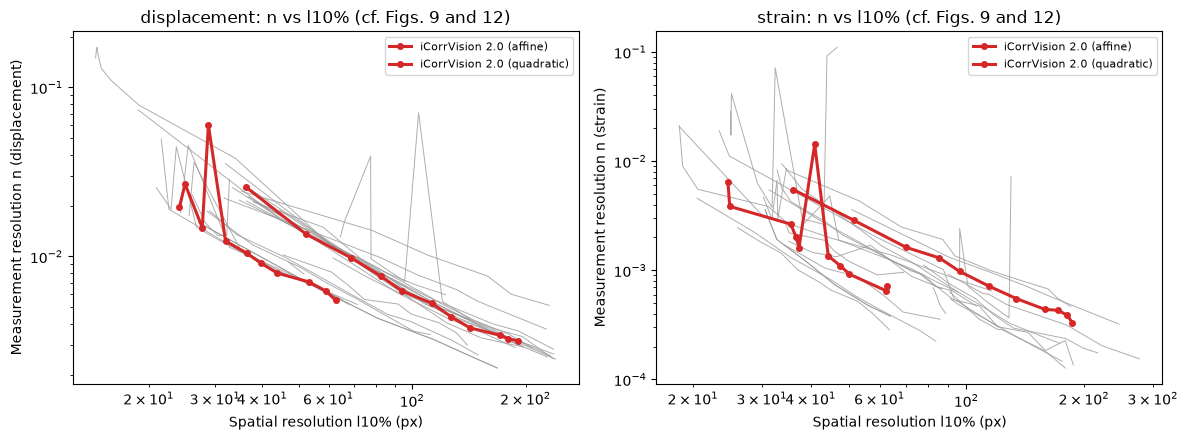

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, quantity in zip(axes, ("displacement", "strain")):
    e = everyone[(everyone.quantity == quantity)]
    for code_name, g in e.groupby("code"):
        ours = code_name.startswith("iCorrVision")
        if ours:
            g = g[g.series == "subset"]  # the subset series traces the n-l curve
        g = g.sort_values("l10_px")
        ax.loglog(g.l10_px, g.n, "o-" if ours else "-", ms=4 if ours else 0,
                  lw=2.2 if ours else 0.7, color=PALETTE["iCorrVision 2.0"] if ours else "0.6",
                  alpha=1 if ours else 0.8, label=code_name if ours else None, zorder=3 if ours else 1)
    ax.set_xlabel("Spatial resolution l10% (px)")
    ax.set_ylabel(f"Measurement resolution n ({quantity})")
    ax.set_title(f"{quantity}: n vs l10% (cf. Figs. 9 and 12)")
    ax.legend(fontsize=8)
fig.tight_layout()


## Figures for Chapter 5

Four figures built from the runs and curves above, so they cost no new correlation. They are written to
`RESULTS/star56/figures/` as PDF for inclusion in the thesis.

1. **How l10% is measured**: one engine line cut, its 12th-order fit, the 90 % line and both crossing rules.
2. **Line cuts across subset sizes**: the attenuation moving to longer periods as the subset grows.
3. **Spatial resolution against subset size**: every code, with the Savitzky–Golay prediction for the
   engine's two shape functions, which links this set to the Star 1 theory check.
4. **MEI against the index of the submitted length parameter**: the flat region the Challenge's
   three-lowest rule relies on, and the degenerate smallest subsets it is meant to ignore.

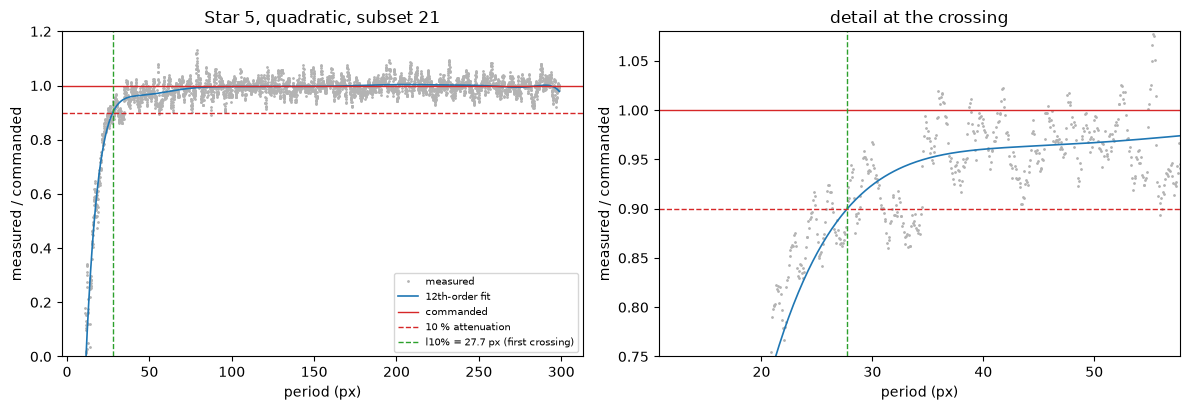

In [13]:
FIG_DIR = RESULTS / "star56" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
LEVEL = 0.9                      # the Challenge's 10 % attenuation criterion
FIG_SHAPE, FIG_SUBSET = "quadratic", 21


def engine_cut(shape: str, subset: int):
    """Period, measured/commanded ratio and the attenuation fit for one Star 5 engine run."""
    x0, v = row_cut(star5_runs[(shape, subset)], S5.deformed, "v_px", ROW5)
    period = S5.period(x0)
    ratio = np.sign(plateau(S5, x0, v)) * v / S5.amplitude
    return period, ratio, fit_attenuation(period, ratio)


def draw_cut(ax, period, ratio, fit, legend=True):
    ok = np.isfinite(ratio)
    grid = np.linspace(period[ok].min(), period[ok].max(), 2000)
    ax.plot(period, ratio, ".", ms=2, color="0.7", label="measured")
    ax.plot(grid, fit.polynomial(grid), color="tab:blue", lw=1.2, label="12th-order fit")
    ax.axhline(1.0, color="tab:red", lw=1, label="commanded")
    ax.axhline(LEVEL, color="tab:red", lw=1, ls="--", label="10 % attenuation")
    ax.axvline(fit.spatial_resolution, color="tab:green", ls="--", lw=1,
               label=f"l10% = {fit.spatial_resolution:.1f} px (first crossing)")
    if np.isfinite(fit.conservative_resolution) and not np.isclose(fit.conservative_resolution,
                                                                  fit.spatial_resolution):
        ax.axvline(fit.conservative_resolution, color="tab:purple", ls=":", lw=1,
                   label=f"{fit.conservative_resolution:.1f} px (stays above)")
    ax.set_xlabel("period (px)")
    ax.set_ylabel("measured / commanded")
    if legend:
        ax.legend(fontsize=7, loc="lower right")


period, ratio, fit = engine_cut(FIG_SHAPE, FIG_SUBSET)
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.2))
draw_cut(left, period, ratio, fit)
left.set_ylim(0.0, 1.2)
left.set_title(f"Star 5, {FIG_SHAPE}, subset {FIG_SUBSET}")
draw_cut(right, period, ratio, fit, legend=False)
centre = fit.spatial_resolution
right.set_xlim(max(period.min(), centre - 30), centre + 30)
right.set_ylim(LEVEL - 0.15, 1.08)
right.set_title("detail at the crossing")
fig.tight_layout()
fig.savefig(FIG_DIR / "star5_l10_definition.pdf")

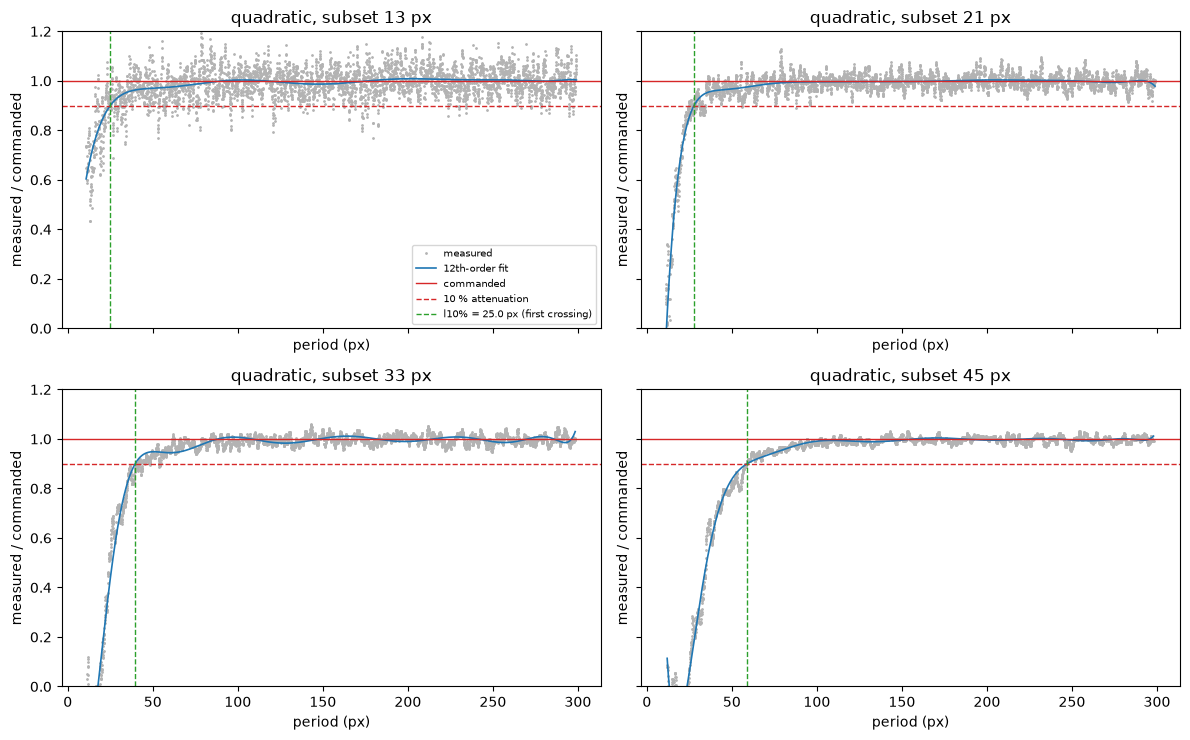

In [14]:
CUT_SUBSETS = [13, 21, 33, 45]
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True, sharey=True)
for ax, subset in zip(axes.ravel(), CUT_SUBSETS):
    draw_cut(ax, *engine_cut(FIG_SHAPE, subset), legend=(subset == CUT_SUBSETS[0]))
    ax.set_ylim(0.0, 1.2)
    ax.set_title(f"{FIG_SHAPE}, subset {subset} px")
fig.tight_layout()
fig.savefig(FIG_DIR / "star5_cuts_by_subset.pdf")

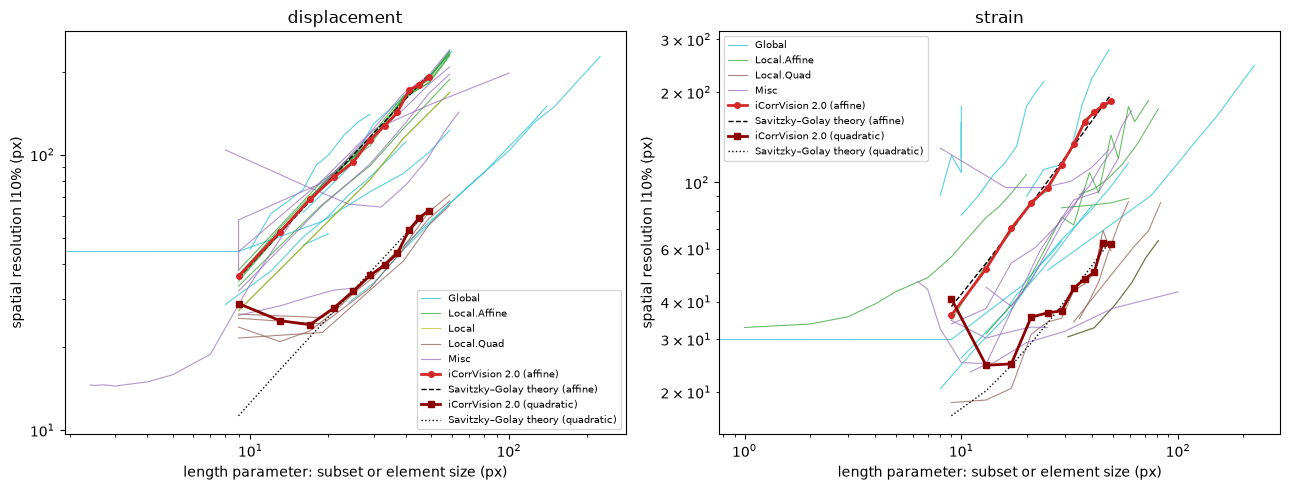

In [15]:
ORDER = {"affine": 1, "quadratic": 2}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, quantity in zip(axes, ("displacement", "strain")):
    e = everyone[everyone.quantity == quantity]
    seen = set()
    for code_name, g in e.groupby("code"):
        fam = family(code_name)
        if fam == "iCorrVision 2.0":
            continue
        g = g.dropna(subset=["parameter", "l10_px"]).sort_values("parameter")
        ax.loglog(g.parameter, g.l10_px, "-", lw=0.8, color=PALETTE[fam], alpha=0.7,
                  label=fam if fam not in seen else None)
        seen.add(fam)
    for shape, marker, colour in (("affine", "o", "tab:red"), ("quadratic", "s", "darkred")):
        g = e[(e.code == f"iCorrVision 2.0 ({shape})") & (e.series == "subset")].sort_values("parameter")
        ax.loglog(g.parameter, g.l10_px, marker + "-", color=colour, ms=4, lw=2,
                  label=f"iCorrVision 2.0 ({shape})", zorder=3)
        extra = {} if quantity == "displacement" else {"strain_window": STRAIN_WINDOW, "step": 1}
        theory = [theoretical_resolution(int(s), ORDER[shape], **extra) for s in PARAMS]
        ax.loglog(PARAMS, theory, "k--" if shape == "affine" else "k:", lw=1,
                  label=f"Savitzky–Golay theory ({shape})")
    ax.set_xlabel("length parameter: subset or element size (px)")
    ax.set_ylabel("spatial resolution l10% (px)")
    ax.set_title(quantity)
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "star56_l10_vs_length.pdf")

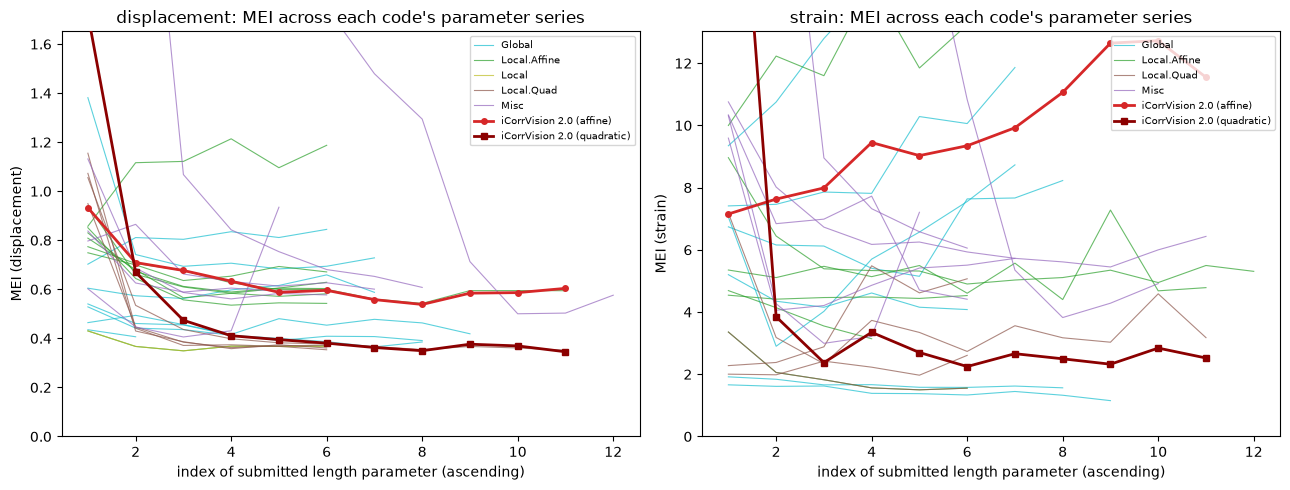

In [16]:
OURS_STYLE = {                                   # same colours and markers as the l10 figure
    "iCorrVision 2.0 (affine)":    {"color": "tab:red", "marker": "o"},
    "iCorrVision 2.0 (quadratic)": {"color": "darkred", "marker": "s"},
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, quantity in zip(axes, ("displacement", "strain")):
    e = everyone[everyone.quantity == quantity]
    seen = set()
    for code_name, g in e.groupby("code"):
        fam = family(code_name)
        ours = fam == "iCorrVision 2.0"
        if ours:
            g = g[g.series == "subset"]
        g = g.sort_values(["parameter"] + (["config"] if "config" in g and not ours else []))
        index = np.arange(1, len(g) + 1)
        if ours:
            style = OURS_STYLE[code_name]
            ax.plot(index, g.mei, "-", marker=style["marker"], ms=4, lw=2,
                    color=style["color"], zorder=3, label=code_name)
        else:
            ax.plot(index, g.mei, "-", lw=0.8, color=PALETTE[fam], alpha=0.7, zorder=1,
                    label=fam if fam not in seen else None)
            seen.add(fam)
    field = ranking[ranking.quantity == quantity].code_mei
    ax.set_ylim(0, 3 * np.nanmedian(field))
    ax.set_xlabel("index of submitted length parameter (ascending)")
    ax.set_ylabel(f"MEI ({quantity})")
    ax.set_title(f"{quantity}: MEI across each code's parameter series")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "star56_mei_vs_index.pdf")

**Optional: full-field maps.** The runs above use a one-row band, so they cannot show the field itself.
This cell correlates the first 200 columns of Star 5 at step 2 for four subset sizes and maps v, which
shows the subset acting as a low-pass filter more directly than any line cut. It needs new correlation
(minutes per subset), so it is off by default.

In [17]:
RUN_FULL_FIELD = False
FULL_FIELD_SUBSETS, FULL_FIELD_COLUMNS, FULL_FIELD_STEP = [13, 21, 33, 45], 200, 2

if RUN_FULL_FIELD:
    import cv2

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
    for ax, subset in zip(axes.ravel(), FULL_FIELD_SUBSETS):
        mask = np.zeros((H5, W5), np.uint8)
        mask[:, :FULL_FIELD_COLUMNS] = 255
        roi = runs5.parent / "roi" / f"full_{FULL_FIELD_COLUMNS}.tiff"
        cv2.imwrite(str(roi), mask)
        point = star_point(subset, FIG_SHAPE, roi)
        point = SweepPoint({**point.overrides, "setup.step_size": FULL_FIELD_STEP})
        outcome = run_point(ds5, runs5, point, repo=REPO, force=FORCE)
        if not outcome.ok:
            continue
        f = load_frame(outcome.output_dir, S5.deformed)
        field = f.pivot(index="y0", columns="x0", values="v_px").where(
            f.pivot(index="y0", columns="x0", values="valid"))
        shown = ax.imshow(field.to_numpy(), origin="upper", cmap="viridis", vmin=-0.5, vmax=0.5,
                          extent=(field.columns.min(), field.columns.max(), field.index.max(), field.index.min()),
                          aspect="auto")
        ax.set_title(f"{FIG_SHAPE}, subset {subset} px")
        ax.set_xlabel("x (px)")
        ax.set_ylabel("y (px)")
    fig.colorbar(shown, ax=axes, label="v (px)", shrink=0.8)
    fig.savefig(FIG_DIR / "star5_full_field.pdf")

## Placement

Each engine variant is ranked **against the participants only**: rank 1 means no participant has a lower
code MEI, and `of` counts the participants plus that one variant. Counting both engine variants in the same
field would rank the engine against itself.

- **primary**: the engine's code MEI from its subset series only, the like-for-like comparison: each
  participant submitted one parameter series.
- **pooled**: all engine configurations, including the strain-window sweep. The minimum over more
  configurations is biased low, so this is reported as a secondary figure, not as the placement.

`gap_to_best_participant_%` is negative when the engine is below every participant. Where it is within a few
percent of zero, the ordinal rank is not meaningful on a single noise realisation, and the margin is the
quantity to compare.

In [18]:
participants_only = ranking[ranking.family != "iCorrVision 2.0"]

placement = []
for protocol, engine_table in (("primary", engine_primary), ("pooled", engine_pooled)):
    for _, row in engine_table.iterrows():
        field = participants_only[participants_only.quantity == row.quantity].code_mei
        best = field.min()
        placement.append({"quantity": row.quantity, "protocol": protocol, "code": row.code,
                          "code_mei": row.code_mei,
                          "rank": 1 + int((field < row.code_mei).sum()), "of": len(field) + 1,
                          "best_participant_mei": best,
                          "gap_to_best_participant_%": 100 * (row.code_mei / best - 1),
                          "participant_median": field.median()})
placement = pd.DataFrame(placement).sort_values(["quantity", "protocol", "code"])
placement.round(3)

,quantity,protocol,code,code_mei,rank,of,best_participant_mei,gap_to_best_participant_%,participant_median
4,displacement,pooled,iCorrVision 2.0 (affine),0.560,14,27,0.356,57.593,0.553
5,displacement,pooled,iCorrVision 2.0 (quadratic),0.353,1,27,0.356,-0.795,0.553
0,displacement,primary,iCorrVision 2.0 (affine),0.560,14,27,0.356,57.593,0.553
1,displacement,primary,iCorrVision 2.0 (quadratic),0.353,1,27,0.356,-0.795,0.553
6,strain,pooled,iCorrVision 2.0 (affine),4.882,16,24,1.271,284.098,4.341
7,strain,pooled,iCorrVision 2.0 (quadratic),2.316,6,24,1.271,82.200,4.341
2,strain,primary,iCorrVision 2.0 (affine),7.591,22,24,1.271,497.240,4.341
3,strain,primary,iCorrVision 2.0 (quadratic),2.316,6,24,1.271,82.200,4.341


**Top of each field.** The five lowest code MEIs among the participants and the engine's primary variants,
so the margin between the leaders is visible rather than implied by a rank.

In [19]:
for quantity, r in ranking.groupby("quantity"):
    top = r.nsmallest(5, "code_mei")[["code", "code_mei"]].reset_index(drop=True)
    top.index += 1
    print(f"\n{quantity}:")
    print(top.round(4).to_string())


displacement:
                          code  code_mei
1  iCorrVision 2.0 (quadratic)    0.3527
2                 Local.Quad.A    0.3555
3               Local.Affine.C    0.3613
4                      Local.B    0.3613
5                 Local.Quad.C    0.3641

strain:
             code  code_mei
1        Global.G    1.2710
2    Local.Quad.C    1.5389
3  Local.Affine.D    1.5389
4        Global.D    1.5748
5    Local.Quad.D    1.9859


**Strain normalisation sensitivity.** The engine's strain code MEI (subset series) under the Green–Lagrange
normalisation used for placement and under the gradient normalisation used for the participants.

In [20]:
strain_engine = everyone[is_engine & (everyone.quantity == "strain") & (everyone.series == "subset")]
sensitivity = pd.DataFrame({
    "green_lagrange (0.05125)": strain_engine.groupby("code").mei.apply(code_mei),
    "gradient (0.05)": strain_engine.groupby("code").mei_gradnorm.apply(code_mei),
})
sensitivity["change_%"] = 100 * (sensitivity.iloc[:, 1] / sensitivity.iloc[:, 0] - 1)
sensitivity.round(4)

,green_lagrange (0.05125),gradient (0.05),change_%
code,,,
iCorrVision 2.0 (affine),7.5912,6.2170,-18.1031
iCorrVision 2.0 (quadratic),2.3159,2.0434,-11.7643


## Crossing-rule sensitivity

Where the Challenge's first-crossing rule and a conservative stays-above-thereafter rule differ by more
than 10 %, a code's measured curve sags back below 90 % at long periods. The Challenge's metric credits
such codes anyway: **l10% is blind to long-period systematic error.** The engine's own configurations are
included in the check, and the finding applies to it as much as to any participant.

In [21]:
split = everyone.assign(gap=everyone.l10_conservative_px / everyone.l10_px - 1)
rules_differ = split[(split.gap.abs() > 0.10) | (split.l10_px.isna() != split.l10_conservative_px.isna())]
rules_differ.groupby(["quantity", "code"]).size().rename("configurations_where_rules_differ")


quantity      code                       
displacement  Local.Affine.H                  6
              Misc.A                          1
              Misc.F                          1
strain        Global.A                        1
              Global.C                        1
              Global.F                        2
              Local.Affine.A                  1
              Local.Affine.B                  1
              Local.Affine.H                  9
              Local.Quad.A                    2
              Misc.A                          2
              Misc.C                          2
              Misc.D                          2
              Misc.E                         10
              Misc.F                          1
              iCorrVision 2.0 (affine)        1
              iCorrVision 2.0 (quadratic)     2
Name: configurations_where_rules_differ, dtype: int64

## Exclusions and corrections

The data-hygiene record for Chapter 5: which submissions were used as submitted, rescaled, corrected or
excluded, and why.

In [22]:
hygiene = pd.concat([r.assign(quantity=q) for q, r in unit_reports.items()], ignore_index=True)
for q, codes in dropped.items():
    for c in codes:
        hygiene.loc[len(hygiene)] = {"quantity": q, "code": c, "unit": "SUPERSEDED by resubmission"}
notes = hygiene[(hygiene.unit != "as submitted") | hygiene.pixel_repaired.fillna(False).astype(bool)]
notes[["quantity", "code", "unit", "plateau", "ratio_to_amplitude", "pixel_repaired"]].round(4)


,quantity,code,unit,plateau,ratio_to_amplitude,pixel_repaired
10,displacement,Local.Affine.D,as submitted,0.4870,0.9740,True
13,displacement,Local.Affine.G,as submitted,0.4879,0.9758,True
17,displacement,Local.Quad.B,as submitted,0.5000,1.0000,True
27,strain,Global.B,percent,4.9936,99.8715,True
35,strain,Local.Affine.D,percent,5.1712,103.4230,False
36,strain,Local.Affine.E,percent,5.0433,100.8665,False
38,strain,Local.Affine.G,EXCLUDED: no known unit,0.0015,0.0292,False
41,strain,Local.Quad.B,as submitted,0.0510,1.0210,True
43,strain,Local.Quad.D,percent,4.9761,99.5230,False
46,strain,Misc.C,percent,4.9528,99.0564,False


## Regression lock

The participant MEIs were frozen once, after the participant bars had been checked against the paper, and
are versioned in `data/star56/participant_mei_frozen.csv`. Every run compares against them and lists anything
that moved by more than 1 %, so a change to the loader or the analysis cannot silently alter a published
comparison. A passing check prints *participant MEIs unchanged*.

In [23]:
out = RESULTS / "star56"
out.mkdir(parents=True, exist_ok=True)
# The frozen file is versioned in the repository: re-freezing from the current run would
# compare the results with themselves and the regression lock could never fail.
FROZEN = REPO / "data" / "star56" / "participant_mei_frozen.csv"
assert FROZEN.is_file(), f"frozen participant MEIs not found: {FROZEN}"
current = ranking[ranking.family != "iCorrVision 2.0"].set_index(["quantity", "code"]).code_mei

frozen = pd.read_csv(FROZEN, index_col=[0, 1]).code_mei
drift = (current / frozen - 1).dropna()
moved = drift[drift.abs() > 0.01]
missing = frozen.index.difference(current.index)
print("participant MEIs unchanged" if moved.empty and missing.empty
      else f"MOVED:\n{moved.round(3)}\nMISSING: {list(missing)}")


participant MEIs unchanged


In [24]:
everyone.to_csv(out / "star56_all_curves.csv", index=False)
ranking.to_csv(out / "star56_code_mei.csv", index=False)
engine_pooled.to_csv(out / "star56_engine_code_mei_pooled.csv", index=False)
placement.to_csv(out / "star56_placement.csv", index=False)
sensitivity.to_csv(out / "star56_strain_normalisation.csv")
window_table.to_csv(out / "star56_strain_window_sweep.csv", index=False)
notes.to_csv(out / "star56_exclusions_corrections.csv", index=False)
for f in ("star56_all_curves.csv", "star56_code_mei.csv", "star56_engine_code_mei_pooled.csv",
          "star56_placement.csv", "star56_strain_normalisation.csv", "star56_strain_window_sweep.csv",
          "star56_exclusions_corrections.csv"):
    print("wrote", out / f)

## Figures for the thesis

Built from the curves and runs above; no new correlation is run. Engine affine is `tab:red` with circles,
engine quadratic `darkred` with squares, participants are coloured by family as in the figures above.
Every figure is written to `FIG_DIR` as PDF.

**Measurement resolution against spatial resolution.** The Challenge's own representation: each curve is
one point, its first-crossing spatial resolution ℓ against its measurement resolution n, and each code's
points are joined in parameter order. The grey lines are constant MEI (n·ℓ for displacement, n·ℓ² for
strain), so moving down and to the left is better. Filled markers are the three lowest MEIs of each code,
the ones its code MEI averages. The engine is shown by its subset series, as in the ranking.

points not drawn because l10 or n is undefined: {'displacement': 0, 'strain': 0}


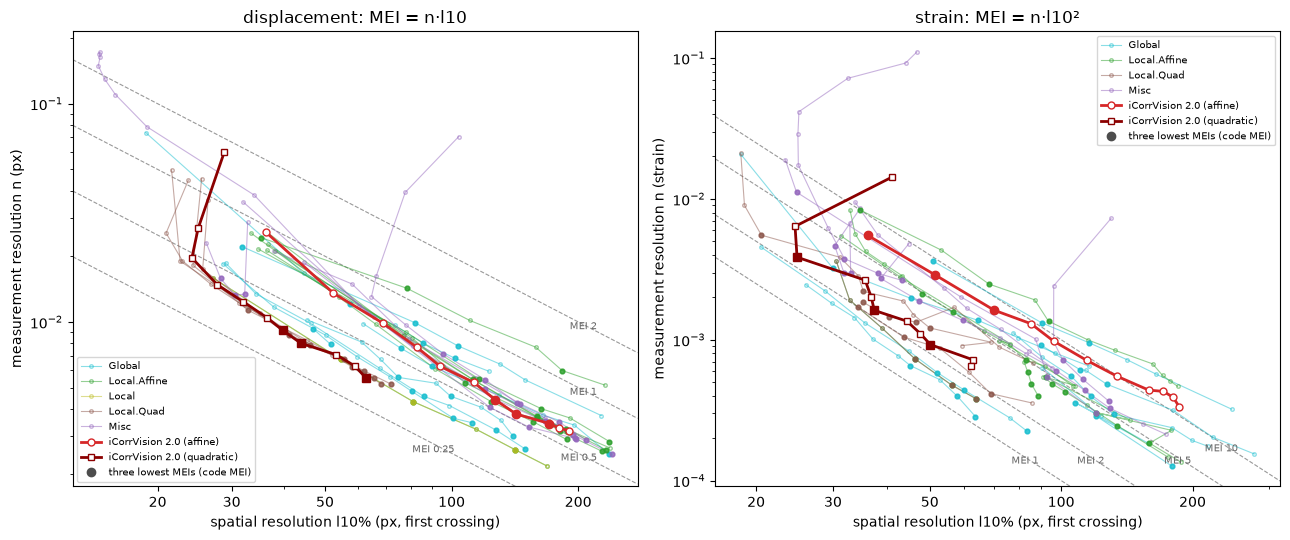

In [25]:
import matplotlib.ticker

ISO_MEI = {"displacement": [0.25, 0.5, 1.0, 2.0], "strain": [1.0, 2.0, 5.0, 10.0]}
EXPONENT = {"displacement": 1, "strain": 2}          # MEI = n * l10**EXPONENT (validation.resolution.mei)
N_UNITS = {"displacement": "px", "strain": "strain"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
undefined = {}
for ax, quantity in zip(axes, ("displacement", "strain")):
    e = everyone[everyone.quantity == quantity]
    e = e[~e.code.str.startswith("iCorrVision") | (e.series == "subset")]
    ok = np.isfinite(e.l10_px) & np.isfinite(e.n) & (e.l10_px > 0) & (e.n > 0)
    undefined[quantity] = int((~ok).sum())
    e = e[ok]
    seen = set()
    for code_name, g in e.groupby("code"):
        fam = family(code_name)
        ours = fam == "iCorrVision 2.0"
        g = g.sort_values(["parameter"] + ([] if ours else ["config"]))
        lowest = g.nsmallest(3, "mei")
        if ours:
            style = OURS_STYLE[code_name]
            ax.plot(g.l10_px, g.n, "-", marker=style["marker"], mfc="white", ms=5, lw=2,
                    color=style["color"], zorder=3, label=code_name)
            ax.plot(lowest.l10_px, lowest.n, style["marker"], ms=6, color=style["color"], zorder=4)
        else:
            ax.plot(g.l10_px, g.n, "-o", ms=2.5, mfc="none", lw=0.8, color=PALETTE[fam], alpha=0.5,
                    zorder=1, label=fam if fam not in seen else None)
            ax.plot(lowest.l10_px, lowest.n, "o", ms=3.5, color=PALETTE[fam], alpha=0.8, zorder=2)
            seen.add(fam)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter("%g"))
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    ax.set_xticks([20, 30, 50, 100, 200])
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    k = EXPONENT[quantity]
    grid = np.geomspace(*xlim, 200)
    for value in ISO_MEI[quantity]:
        ax.plot(grid, value / grid**k, color="0.6", lw=0.8, ls="--", zorder=0)
        x = xlim[1] / 1.25                           # label near the right edge, or where the line leaves the bottom
        if not ylim[0] < value / x**k < ylim[1]:
            x = (value / (ylim[0] * 1.4)) ** (1 / k)
        if xlim[0] < x < xlim[1]:
            ax.text(x, value / x**k, f"MEI {value:g}", fontsize=7, color="0.4", ha="right", va="bottom")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot([], [], "o", color="0.3", label="three lowest MEIs (code MEI)")
    ax.set_xlabel("spatial resolution l10% (px, first crossing)")
    ax.set_ylabel(f"measurement resolution n ({N_UNITS[quantity]})")
    ax.set_title(f"{quantity}: MEI = n·l10" + ("²" if k == 2 else ""))
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "star56_n_vs_l10.pdf")
print("points not drawn because l10 or n is undefined:", undefined)


**Star 5 line cut: engine against the best participants.** The centre-row displacement against the local
period for the engine (quadratic) at the subset of its lowest MEI, for the participant with the lowest
displacement code MEI, and for the best code of the Global family, each at its own lowest-MEI
configuration. All are sign-corrected from the long-period plateau, as in the l10 definition figure. The
best participant is a subset method like the engine and nearly coincides with it; the Global code shows
how a different formulation attenuates. The inset enlarges the short-period end; the lower panel shows
each participant minus the engine, node by node on the columns both report.

Local.Quad.A: code MEI 0.3555; parameter 49, config 10, MEI 0.3514, l10 62.8 px
Global.D: code MEI 0.3791; parameter 36, config 6, MEI 0.3651, l10 100.9 px
engine: quadratic, subset 49, MEI 0.3455, l10 62.7 px
Local.Quad.A − engine: 3952 common columns, RMS 0.0016 px, max |diff| 0.0116 px
Global.D − engine: 3952 common columns, RMS 0.1710 px, max |diff| 0.5732 px


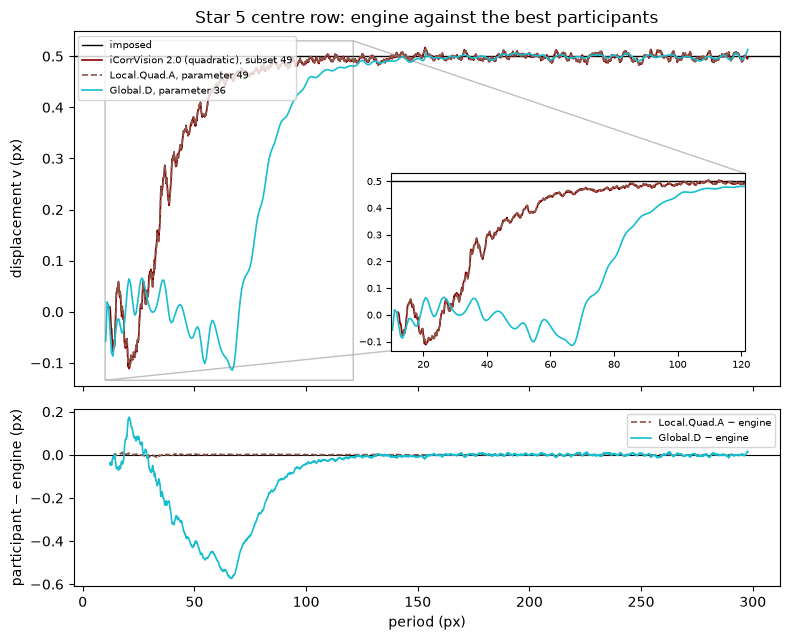

In [26]:
disp = everyone[everyone.quantity == "displacement"]
participant_codes = ranking[(ranking.quantity == "displacement") & (ranking.family != "iCorrVision 2.0")]
chosen = [participant_codes.nsmallest(1, "code_mei").iloc[0],
          participant_codes[participant_codes.family == "Global"].nsmallest(1, "code_mei").iloc[0]]
engine_curve = (disp[(disp.code == "iCorrVision 2.0 (quadratic)") & (disp.series == "subset")]
                .nsmallest(1, "mei").iloc[0])

ex0, ev = row_cut(star5_runs[("quadratic", int(engine_curve.parameter))], S5.deformed, "v_px", ROW5)
ev = np.sign(plateau(S5, ex0, ev)) * ev
engine_by_column = pd.Series(ev, index=np.rint(ex0).astype(int))

cut = participant_tables["displacement"]
lines = [(S5.period(ex0), ev, f"iCorrVision 2.0 (quadratic), subset {int(engine_curve.parameter)}",
          {"color": "darkred", "lw": 1.2}, None)]
l10s = [engine_curve.l10_px]
for code, ls in zip(chosen, ("--", "-")):
    curve = disp[disp.code == code.code].nsmallest(1, "mei").iloc[0]
    d = cut[(cut.code == code.code) & (cut.config == curve.config) & (cut.image == "deformed")].sort_values("pixel")
    x0, v = d.pixel.to_numpy() - 1, d.value.to_numpy()
    v = np.sign(plateau(S5, x0, v)) * v
    l10s.append(curve.l10_px)
    lines.append((S5.period(x0), v, f"{code.code}, parameter {curve.parameter:g}",
                  {"color": PALETTE[code.family], "lw": 1.2, "ls": ls}, (x0, v)))
    print(f"{code.code}: code MEI {code.code_mei:.4f}; parameter {curve.parameter:g}, config {curve.config:g}, "
          f"MEI {curve.mei:.4f}, l10 {curve.l10_px:.1f} px")
print(f"engine: quadratic, subset {int(engine_curve.parameter)}, MEI {engine_curve.mei:.4f}, "
      f"l10 {engine_curve.l10_px:.1f} px")

fig, (ax, lower) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, height_ratios=[2, 1])
inset = ax.inset_axes([0.45, 0.1, 0.5, 0.5])
short = 1.2 * max(l10s)                          # the inset spans every curve's attenuation
for target in (ax, inset):
    target.axhline(S5.amplitude, color="k", lw=1, label="imposed")
    for period, value, label, style, _ in lines:
        target.plot(period, value, label=label, **style)
inset.set_xlim(min(np.nanmin(line[0]) for line in lines), short)
near = [line[1][line[0] <= short] for line in lines]
inset.set_ylim(min(np.nanmin(v) for v in near) - 0.02, S5.amplitude + 0.03)
inset.tick_params(labelsize=7)
ax.indicate_inset_zoom(inset, edgecolor="0.5")
ax.set_ylabel("displacement v (px)")
ax.set_title("Star 5 centre row: engine against the best participants")
ax.legend(fontsize=7, loc="upper left")

lower.axhline(0, color="k", lw=0.8)
for period, value, label, style, raw in lines[1:]:
    x0, v = raw
    columns = np.rint(x0).astype(int)
    common = np.isin(columns, engine_by_column.index)
    difference = v[common] - engine_by_column.loc[columns[common]].to_numpy()
    lower.plot(S5.period(x0[common]), difference, label=f"{label.split(',')[0]} − engine", **style)
    print(f"{label.split(',')[0]} − engine: {common.sum()} common columns, "
          f"RMS {np.sqrt(np.nanmean(difference**2)):.4f} px, max |diff| {np.nanmax(np.abs(difference)):.4f} px")
lower.set_xlabel("period (px)")
lower.set_ylabel("participant − engine (px)")
lower.legend(fontsize=7, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "star5_linecut_best.pdf")


**Non-convergence against subset size.** The share of valid nodes whose IC-GN iteration did not reach its
tolerance, for both shape functions, on Star 1 (from `star1_resolution_vs_theory.csv`, written by the Star 1
notebook) and on Stars 5 and 6 (the subset series above). Most values are exactly zero, so the y axis is
symmetric-logarithmic: linear below the threshold printed with the figure, logarithmic above it.

y axis: symlog, linear below 0.1 %
    Star 1 (affine)  Star 1 (quadratic)  Star 5 (displacement) (affine)  Star 5 (displacement) (quadratic)  Star 6 (strain) (affine)  Star 6 (strain) (quadratic)
9             0.959               9.124                           0.364                             10.612                     0.206                        9.984
13            0.000               0.556                           0.000                              0.163                     0.000                        0.138
17            0.000               0.000                           0.000                              0.000                     0.000                        0.000
21              NaN                 NaN                           0.000                              0.000                     0.000                        0.000
25            0.000               0.000                           0.000                              0.000                     0.000                       

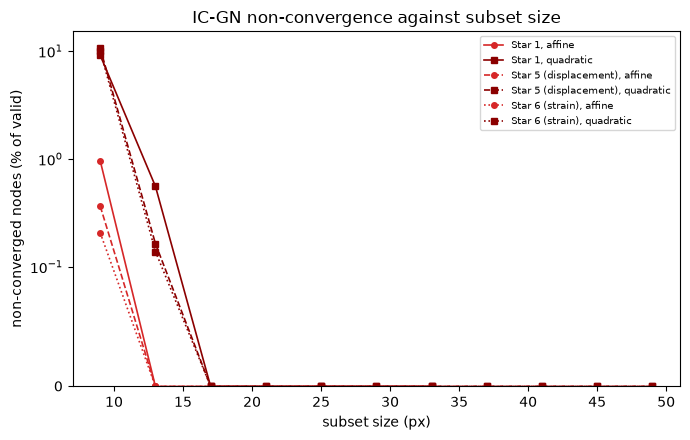

In [27]:
STAR1_CSV = RESULTS / "star1" / "star1_resolution_vs_theory.csv"
series = []
if STAR1_CSV.exists():
    star1 = pd.read_csv(STAR1_CSV)
    for shape in SHAPES:
        g = star1[star1["shape"] == shape].sort_values("subset")
        series.append(("Star 1", shape, g.subset, g.nonconverged_pct, "-"))
else:
    print(f"WARNING: {STAR1_CSV} not found; run the Star 1 notebook first. Plotting Stars 5 and 6 only.")
subset_series = everyone[everyone.code.str.startswith("iCorrVision") & (everyone.series == "subset")]
for star, quantity, ls in (("Star 5 (displacement)", "displacement", "--"), ("Star 6 (strain)", "strain", ":")):
    for shape in SHAPES:
        g = subset_series[(subset_series.quantity == quantity)
                          & (subset_series.code == f"iCorrVision 2.0 ({shape})")].sort_values("parameter")
        series.append((star, shape, g.parameter, g.nonconverged_pct, ls))

positive = np.concatenate([np.asarray(s[3], float) for s in series])
positive = positive[positive > 0]
linthresh = 10.0 ** np.floor(np.log10(positive.min()))

fig, ax = plt.subplots(figsize=(7, 4.5))
for star, shape, subset, pct, ls in series:
    style = OURS_STYLE[f"iCorrVision 2.0 ({shape})"]
    ax.plot(subset, pct, ls, marker=style["marker"], color=style["color"], ms=4, lw=1.2,
            label=f"{star}, {shape}")
ax.set_yscale("symlog", linthresh=linthresh)
ax.set_ylim(bottom=0)
ax.set_xlabel("subset size (px)")
ax.set_ylabel("non-converged nodes (% of valid)")
ax.set_title("IC-GN non-convergence against subset size")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "nonconvergence_vs_subset.pdf")
print(f"y axis: symlog, linear below {linthresh:g} %")
print(pd.DataFrame({f"{s} ({sh})": pd.Series(np.asarray(p, float), index=np.asarray(x, int))
                    for s, sh, x, p, _ in series}).round(3).to_string())
